In [2]:
import pandas as pd

df = pd.read_excel('Result_28.xlsx')

In [3]:
if __name__ == "__main__":

    print("Valores nulos restantes por coluna:")
    print(df.isnull().sum())

Valores nulos restantes por coluna:
tipo_ticket                0
problema_nosso         21673
servico                19997
meio                       0
status_cliente             0
categoria               2440
hist                   19214
codcli                     0
consultor                  4
classificacao              0
data_criacao_ticket        0
id_ticket                  0
titulo                    11
colaborador            26703
data_atualizacao           0
duracao                47016
mensagem                2919
dtype: int64


In [4]:
# 1. Tratamento do tempo e criação da coluna de minutos
df["duracao"] = df["duracao"].fillna("00:00:00")
df["duracao"] = pd.to_timedelta(df["duracao"], errors="coerce")
df["data_atualizacao"] = pd.to_datetime(df["data_atualizacao"], errors="coerce")

# Converter durações para formato HH:MM:SS (string) removendo 'days'
df['duracao_minutos_individual'] = df['duracao'].astype(str).str.replace(r'^(\d+ days?\s+)?', '', regex=True).str.split('.').str[0]

# 2. Somar a duração por ticket e criar coluna separada
df['duracao_minutos_total_por_ticket'] = df.groupby('id_ticket')['duracao'].transform('sum').astype(str).str.split('.').str[0]


# 3. Lista de colunas que NÃO queremos que o preenchimento automático toque
# (duracao já está preenchida, mensagem não será alterada, id_ticket é a chave)
colunas_ignoradas = ['id_ticket', 'duracao', 'duracao_minutos_individual', 'mensagem', 'duracao_minutos_total_por_ticket']

# Criar a lista de colunas para preencher (todas as outras colunas)
colunas_para_preencher = [col for col in df.columns if col not in colunas_ignoradas]

# 4. Preencher as lacunas em bloco (bfill e ffill) para cada ticket
df[colunas_para_preencher] = df.groupby('id_ticket')[colunas_para_preencher].transform(
    lambda x: x.bfill().ffill()
)
# 5. Remover a coluna de duração original, pois agora temos as colunas de minutos
df = df.drop('duracao', axis=1)

# 6. Remover os status pendentes, pois não são mais relevantes para a análise
df = df[df["status_cliente"].isin(["FECHADO"])]
df = df.dropna(subset=["status_cliente"])

# 7. Preencher valores nulos na coluna "problema_nosso"
df["problema_nosso"] = df["problema_nosso"].fillna("Indefinido", inplace= True)

# 8. Preencher valores nulos na coluna "servico"
df['servico'] = df['servico'].fillna("Serviço Indefinido", inplace= True)

# 9. Preencher valores nulos na coluna "categoria"
df['categoria'] = df['categoria'].fillna("Categoria Indefinida", inplace= True)

# 10. Preencher valores nulos na coluna "hist"
df['hist'] = df['hist'].fillna("Versão Indefinido", inplace= True)

# 11. Preencher valores nulos na coluna "consultor"
df['consultor'] = df['consultor'].fillna("Indefinido", inplace= True)

# 12. Preencher valores nulos na coluna "titulo"
df['titulo'] = df['titulo'].fillna("Sem título", inplace= True)

# 13. Preencher valores nulos na coluna "colaborador"
df['colaborador'] = df['colaborador'].fillna("Colaborador Indefinido", inplace= True)

# 14. Preencher valores nulos na coluna "data_atualizacao"
df['data_atualizacao'] = df['data_atualizacao'].fillna("00:00:00")

# 15. Preencher valores nulos na coluna "mensagem" e limpar caracteres de quebra de linha
df['mensagem'] = df['mensagem'].fillna("Sem mensagem", inplace= True)
# Remove "mailto:"
df["mensagem"] = df["mensagem"].str.replace("mailto:", "", regex=False)
# Remove emails
df["mensagem"] = df["mensagem"].str.replace(
    r'\S+@\S+',
    '',
    regex=True
)
# Remove entidades HTML &nbsp;
df["mensagem"] = df["mensagem"].str.replace("&nbsp;", " ", regex=False)
# Remove espaços extras novamente
df["mensagem"] = df["mensagem"].str.replace(r'\s+', ' ', regex=True).str.strip()

# 16. Ordenar categoria por ordem alfabética
ordem = ["A", "B", "C"]

df["classificacao"] = pd.Categorical(
    df["classificacao"],
    categories=ordem,
    ordered=True
)

df = df.sort_values("classificacao")


if __name__ == "__main__":

    print("Valores nulos restantes por coluna:")
    print(df.isnull().sum())

C:\Users\44275289889\AppData\Local\Temp\ipykernel_33452\1743789501.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["problema_nosso"] = df["problema_nosso"].fillna("Indefinido", inplace= True)
C:\Users\44275289889\AppData\Local\Temp\ipykernel_33452\1743789501.py:35: ChainedAssignmentError: A value is being set on a copy of a D

Valores nulos restantes por coluna:
tipo_ticket                         0
problema_nosso                      0
servico                             0
meio                                0
status_cliente                      0
categoria                           0
hist                                0
codcli                              0
consultor                           0
classificacao                       0
data_criacao_ticket                 0
id_ticket                           0
titulo                              0
colaborador                         0
data_atualizacao                    0
mensagem                            0
duracao_minutos_individual          0
duracao_minutos_total_por_ticket    0
dtype: int64


In [5]:
df

,tipo_ticket,problema_nosso,servico,meio,status_cliente,categoria,hist,codcli,consultor,classificacao,data_criacao_ticket,id_ticket,titulo,colaborador,data_atualizacao,mensagem,duracao_minutos_individual,duracao_minutos_total_por_ticket
43108,suporte,Indefinido,Serviço Indefinido,Portal Cliente,FECHADO,Nova Solicitação,Versão Indefinido,5463,Julio Cesar,A,2025-06-09 04:55,358272,Liberar site,Cleverton,2025-06-09 04:55:00,Liberar site,00:00:00,0 days 00:03:12
90135,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 40F s/ lic - Palmas Embrasil,4968,Janaina,A,2025-11-07 11:55,371606,Embrasil - Palmas Voip 3cx,João Paulo,2025-11-07 01:55:00,"Prezados, boa tarde.Configuração realizada par...",00:07:09,0 days 00:07:09
39400,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 04:55:00,Incluir servidores na regra do anydesk,00:00:00,0 days 00:17:00
39401,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 04:55:00,"Prezados,Boa tarde.Preciso que seja incluído n...",00:00:00,0 days 00:17:00
39402,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 05:55:00,"Navito, boa tarde!Conforme as regras criadas a...",00:04:42,0 days 00:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56537,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 03:55:00,Sem mensagem,00:00:37,0 days 00:07:14
56536,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 08:55:00,Estamos com um rompimento no trecho acima cons...,00:01:12,0 days 00:07:14
56535,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 08:55:00,Rompimento - MKT LOG - 28/07/2025,00:00:00,0 days 00:07:14
56531,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Nova Solicitação,Rompimento,4873,CTI-ADM,C,2025-07-26 01:55,362033,Rompimento - 5557-SMARTS_AVENIDA_POMPEIA-LD e ...,Ermerson,2025-07-26 07:55:00,"https://maps.google.com/?q=-23.5274437,-46.683...",00:03:24,0 days 00:40:30


In [6]:
    # =========================================================
    # BASE
    # =========================================================

    df_servico = (
        df.groupby(['colaborador', 'servico'])['id_ticket']
        .nunique()
        .reset_index(name='tickets_resolvidos')
    )

    df_servico = df_servico.dropna(subset=['colaborador', 'servico'])

    # =========================================================
    # LIMIAR
    # =========================================================

    LIMIAR_APTIDAO = 200

    # =========================================================
    # CLASSIFICAÇÃO POR SERVIÇO
    # =========================================================

    df_servico['apto'] = df_servico['tickets_resolvidos'] >= LIMIAR_APTIDAO

    # =========================================================
    # 1) APTOS POR SERVIÇO (SEM DUPLICAR)
    # =========================================================

    aptos = df_servico[df_servico['apto']].copy()

    print("\n===== COLABORADORES APTOS POR SERVIÇO =====\n")

    for servico, grupo in aptos.groupby('servico'):

        print(f"\n🔧 SERVIÇO: {servico}")
        print("-" * 50)

        grupo = grupo.sort_values('tickets_resolvidos', ascending=False)

        for _, row in grupo.iterrows():

            print(f"{row['colaborador']} | {row['tickets_resolvidos']} tickets")

    # =========================================================
    # 2) NÃO APTOS (SOMENTE QUEM NÃO É APT0 EM NENHUM SERVIÇO)
    # =========================================================

    nao_aptos = (
        df_servico
        .groupby('colaborador')
        .filter(lambda x: not x['apto'].any())
    )

    nao_aptos = (
        nao_aptos.groupby('colaborador')['tickets_resolvidos']
        .sum()
        .reset_index()
        .sort_values('tickets_resolvidos')
    )

    print("\n===== NÃO APTOS PARA NENHUM SERVIÇO =====\n")

    for _, row in nao_aptos.iterrows():
        print(f"{row['colaborador']} | {row['tickets_resolvidos']} tickets")


===== COLABORADORES APTOS POR SERVIÇO =====


🔧 SERVIÇO: Acesso Dedicado
--------------------------------------------------
Endrew | 1363 tickets
Rodolfo | 1104 tickets
Allan | 999 tickets
Wilhard | 933 tickets
Gustavo | 736 tickets
Marcos | 596 tickets
Rafael Gomes | 573 tickets
Thiago | 521 tickets
Miriam | 337 tickets
Vitor | 302 tickets
Jhennifer | 237 tickets
Lucas | 225 tickets
Yuri | 218 tickets

🔧 SERVIÇO: Antivirus
--------------------------------------------------
Lucas | 250 tickets
Thiago | 201 tickets

🔧 SERVIÇO: Backup
--------------------------------------------------
Thiago | 334 tickets
Danilo | 275 tickets

🔧 SERVIÇO: E-mail
--------------------------------------------------
Thiago | 870 tickets
Danilo | 645 tickets
Tiago | 421 tickets
Davi | 220 tickets

🔧 SERVIÇO: Fortinet
--------------------------------------------------
Lucas | 2868 tickets
João Paulo | 1480 tickets
Tiago | 1383 tickets
Vitor | 1039 tickets
Thiago | 790 tickets
Cleverton | 782 tickets
Felipe | 6

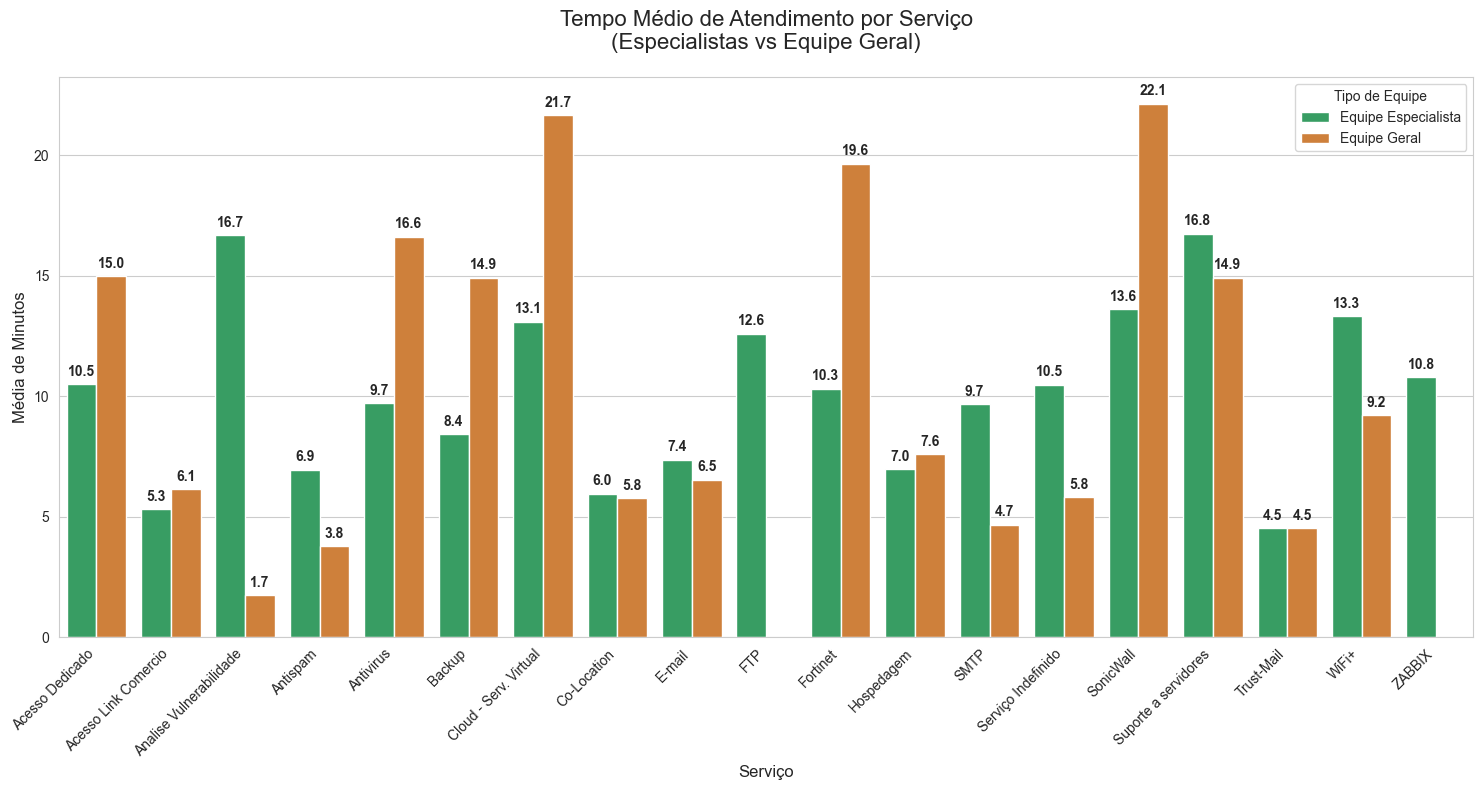

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. TRATAMENTO SEGURO (VERIFICANDO COLUNAS)
# =========================================================

# Se você já rodou o drop, a coluna original sumiu. 
# Vamos garantir que as colunas de tempo existam para o cálculo.
if 'duracao' in df.columns:
    df["duracao"] = df["duracao"].fillna("00:00:00")
    # Criamos uma coluna auxiliar em formato Timedelta (numérico)
    df["duracao_real"] = pd.to_timedelta(df["duracao"], errors="coerce").fillna(pd.Timedelta(seconds=0))
elif 'duracao_minutos_individual' in df.columns:
    # Caso 'duracao' não exista, mas a string que você criou exista:
    df["duracao_real"] = pd.to_timedelta(df["duracao_minutos_individual"], errors="coerce").fillna(pd.Timedelta(seconds=0))
else:
    print("ERRO: Nenhuma coluna de duração encontrada. Recarregue a base original.")

# Limpeza de nulos (SEM inplace=True para não apagar os dados)
colunas_texto = ["servico", "colaborador", "status_cliente"]
for col in colunas_texto:
    if col in df.columns:
        df[col] = df[col].fillna(f"{col} Indefinido")

# Transformar o tempo em Minutos (Float) para o gráfico conseguir calcular a média
df['minutos_num'] = df['duracao_real'].dt.total_seconds() / 60

# =========================================================
# 2. DEFINIR QUEM SÃO OS ESPECIALISTAS (APTOS)
# =========================================================
# Baseado na sua lista: quem tem >= 200 tickets em algum serviço
aptos_list = (
    df.groupby(['colaborador', 'servico'])['id_ticket']
    .nunique()
    .reset_index()
)
especialistas = aptos_list[aptos_list['id_ticket'] >= 200]['colaborador'].unique()

# Criar coluna de Equipe
df['equipe'] = df['colaborador'].apply(
    lambda x: 'Equipe Especialista' if x in especialistas else 'Equipe Geral'
)

# =========================================================
# 3. GERAR O GRÁFICO DE TEMPO MÉDIO POR SERVIÇO E EQUIPE
# =========================================================

# Filtrar apenas tickets fechados e remover tempos zerados (opcional, melhora a média)
df_filtrado = df[(df["status_cliente"] == "FECHADO") & (df["minutos_num"] > 0)].copy()

# Agrupar para o gráfico
df_grafico = df_filtrado.groupby(['servico', 'equipe'])['minutos_num'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Criar o gráfico
plot = sns.barplot(
    data=df_grafico,
    x='servico',
    y='minutos_num',
    hue='equipe',
    palette={'Equipe Especialista': '#27ae60', 'Equipe Geral': '#e67e22'}
)

# Customização
plt.title('Tempo Médio de Atendimento por Serviço\n(Especialistas vs Equipe Geral)', fontsize=16, pad=20)
plt.ylabel('Média de Minutos', fontsize=12)
plt.xlabel('Serviço', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Equipe')

# Adicionar os valores nas barras
for p in plot.patches:
    if p.get_height() > 0:
        plot.annotate(format(p.get_height(), '.1f'), 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha = 'center', va = 'center', 
                      xytext = (0, 9), 
                      textcoords = 'offset points',
                      fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

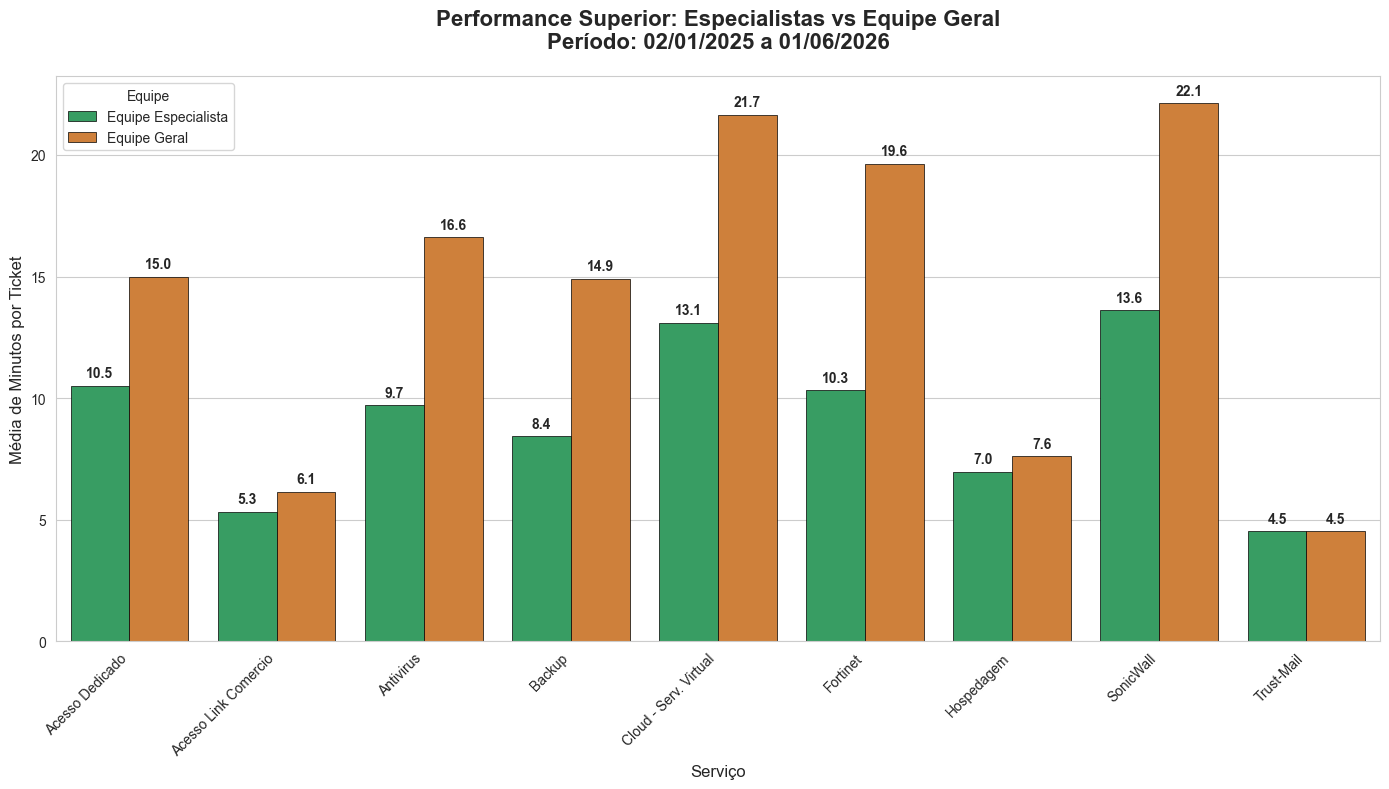


RELATÓRIO DE PERFORMANCE - PERÍODO: 02/01/2025 A 01/06/2026
SERVIÇOS ONDE A EQUIPE GERAL FOI MAIS RÁPIDA (OU IGUAL)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
❌ SERVIÇO: Analise Vulnerabilidade
   • Média Especialista: 16.69 min
   • Média Equipe Geral: 1.74 min
   • Diferença: +14.95 min (Especialista mais lento)
----------------------------------------
❌ SERVIÇO: Antispam
   • Média Especialista: 6.94 min
   • Média Equipe Geral: 3.77 min
   • Diferença: +3.17 min (Especialista mais lento)
----------------------------------------
❌ SERVIÇO: Co-Location
   • Média Especialista: 5.95 min
   • Média Equipe Geral: 5.76 min
   • Diferença: +0.19 min (Especialista mais lento)
----------------------------------------
❌ SERVIÇO: E-mail
   • Média Especialista: 7.36 min
   • Média Equipe Geral: 6.53 min
   • Diferença: +0.83 min (Especialista mais lento)
----------------------------------------
❌ SERVIÇO: SMTP
   • Média Especialista: 9.66 min
   • Média Equipe Geral: 4.66 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 0. CÁLCULO DO PERÍODO ANALISADO
# =========================================================
data_inicio = df_filtrado['data_atualizacao'].min().strftime('%d/%m/%Y')
data_fim = df_filtrado['data_atualizacao'].max().strftime('%d/%m/%Y')
dias_totais = (df_filtrado['data_atualizacao'].max() - df_filtrado['data_atualizacao'].min()).days

# Define o rótulo do período
if dias_totais <= 7:
    periodo_txt = f"Semanal ({data_inicio} a {data_fim})"
elif dias_totais <= 31:
    periodo_txt = f"Mensal ({data_inicio} a {data_fim})"
else:
    periodo_txt = f"Período: {data_inicio} a {data_fim}"

# =========================================================
# 1. PROCESSAMENTO DOS DADOS (FILTRO DE EFICIÊNCIA)
# =========================================================
df_comparativo = df_filtrado.groupby(['servico', 'equipe'])['minutos_num'].mean().unstack()

# Filtrar apenas onde Especialista é MAIS RÁPIDO
mask_eficiente = df_comparativo['Equipe Especialista'] < df_comparativo['Equipe Geral']
df_eficientes = df_comparativo[mask_eficiente].stack().reset_index(name='minutos_num')
df_nao_eficientes = df_comparativo[~mask_eficiente]

# =========================================================
# 2. GRÁFICO COM PERÍODO NO TÍTULO
# =========================================================
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

cores = {'Equipe Especialista': '#27ae60', 'Equipe Geral': '#e67e22'}

plot = sns.barplot(
    data=df_eficientes,
    x='servico',
    y='minutos_num',
    hue='equipe',
    palette=cores,
    edgecolor='black',
    linewidth=0.5
)

# Título Dinâmico
plt.title(f'Performance Superior: Especialistas vs Equipe Geral\n{periodo_txt}', 
          fontsize=16, fontweight='bold', pad=20)

plt.ylabel('Média de Minutos por Ticket', fontsize=12)
plt.xlabel('Serviço', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Equipe', frameon=True)

for p in plot.patches:
    if p.get_height() > 0:
        plot.annotate(format(p.get_height(), '.1f'), 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha = 'center', va = 'center', 
                      xytext = (0, 9), 
                      textcoords = 'offset points',
                      fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================
# 3. RELATÓRIO COM CABEÇALHO DE TEMPO
# =========================================================
print("\n" + "="*60)
print(f"RELATÓRIO DE PERFORMANCE - {periodo_txt.upper()}")
print("="*60)
print("SERVIÇOS ONDE A EQUIPE GERAL FOI MAIS RÁPIDA (OU IGUAL)")
print("!"*60)

if df_nao_eficientes.empty:
    print("✨ Incrível! Em todos os serviços, os especialistas foram mais rápidos.")
else:
    df_nao_eficientes = df_nao_eficientes.dropna()
    
    for servico, row in df_nao_eficientes.iterrows():
        diff = row['Equipe Especialista'] - row['Equipe Geral']
        print(f"❌ SERVIÇO: {servico}")
        print(f"   • Média Especialista: {row['Equipe Especialista']:.2f} min")
        print(f"   • Média Equipe Geral: {row['Equipe Geral']:.2f} min")
        print(f"   • Diferença: +{diff:.2f} min (Especialista mais lento)")
        print("-" * 40)

In [9]:
# =========================================================
# 1. CÁLCULO DAS MÉDIAS PARA COMPARAÇÃO
# =========================================================
# Tempo em minutos
df['minutos_num'] = pd.to_timedelta(df['duracao_minutos_total_por_ticket'], errors='coerce').dt.total_seconds() / 60

# Identificar quem é a "Equipe Geral" (quem não atingiu 200 tickets em nada)
df_vol_base = df.groupby(['colaborador', 'servico'])['id_ticket'].nunique().reset_index(name='vol')
colaboradores_geral = df_vol_base.groupby('colaborador').filter(lambda x: not (x['vol'] >= 200).any())['colaborador'].unique()

# Média de tempo da Equipe Geral por serviço (nossa régua)
media_geral_servico = (
    df[(df['colaborador'].isin(colaboradores_geral)) & (df['status_cliente'] == "FECHADO")]
    .groupby('servico')['minutos_num']
    .mean()
)

# =========================================================
# 2. IDENTIFICAÇÃO DOS SERVIÇOS ONDE O ESPECIALISTA É LENTO
# =========================================================
# Média de tempo de quem tem >= 200 tickets
media_especialista_servico = (
    df[~df['colaborador'].isin(colaboradores_geral) & (df['status_cliente'] == "FECHADO")]
    .groupby('servico')['minutos_num']
    .mean()
)

# Lista de serviços onde a média do especialista é pior (maior) que a do geral
servicos_para_desmembrar = []
for serv in media_especialista_servico.index:
    m_esp = media_especialista_servico.get(serv)
    m_ger = media_geral_servico.get(serv, 999999) # Se não houver geral, mantém especialista
    
    if m_esp >= m_ger:
        servicos_para_desmembrar.append(serv)

# =========================================================
# 3. RELATÓRIO FINAL (O SEU FORMATO ORIGINAL)
# =========================================================

# 1) APTOS QUE SE MANTIVERAM (ÁGEIS)
print("\n" + "="*60)
print("🏆 COLABORADORES APTOS E EFICIENTES (MANTIDOS)")
print("="*60)

# Pegamos os aptos (>= 200) que NÃO estão nos serviços desmembrados
aptos_eficientes = df_vol_base[(df_vol_base['vol'] >= 200) & (~df_vol_base['servico'].isin(servicos_para_desmembrar))]

for servico, grupo in aptos_eficientes.groupby('servico'):
    print(f"\n⚡ SERVIÇO: {servico}")
    print("-" * 30)
    for _, row in grupo.sort_values('vol', ascending=False).iterrows():
        print(f"{row['colaborador']} | {row['vol']} tickets")

# 2) O GERALZÃO (UNIFICADO: NÃO APTOS + ESPECIALISTAS LENTOS)
print("\n" + "!"*60)
print("📦 GERALZÃO: EQUIPE UNIFICADA (NÃO APTOS + DESMEMBRADOS POR LENTIDÃO)")
print("!"*60)

# Parte A: Quem já não era apto (Seu código original)
nao_aptos_originais = df_vol_base.groupby('colaborador').filter(lambda x: not (x['vol'] >= 200).any())

# Parte B: Quem era apto mas o serviço foi desmembrado por ser lento
aptos_desmembrados = df_vol_base[(df_vol_base['vol'] >= 200) & (df_vol_base['servico'].isin(servicos_para_desmembrar))]

# Juntando tudo no Geralzão
geralzao_final = pd.concat([nao_aptos_originais, aptos_desmembrados])

# Exibição consolidada por Colaborador
resumo_geralzao = geralzao_final.groupby('colaborador')['vol'].sum().reset_index().sort_values('vol', ascending=False)

for _, row in resumo_geralzao.iterrows():
    # Identificar se ele veio por falta de volume ou por lentidão do serviço
    if row['colaborador'] in aptos_desmembrados['colaborador'].values:
        tag = "[ESPECIALISTA DESMEMBRADO POR TEMPO]"
    else:
        tag = "[NÃO APTO ORIGINAL]"
        
    print(f"{row['colaborador']} | {row['vol']} tickets total {tag}")


🏆 COLABORADORES APTOS E EFICIENTES (MANTIDOS)

⚡ SERVIÇO: Acesso Dedicado
------------------------------
Endrew | 1363 tickets
Rodolfo | 1104 tickets
Allan | 999 tickets
Wilhard | 933 tickets
Gustavo | 736 tickets
Marcos | 596 tickets
Rafael Gomes | 573 tickets
Thiago | 521 tickets
Miriam | 337 tickets
Vitor | 302 tickets
Jhennifer | 237 tickets
Lucas | 225 tickets
Yuri | 218 tickets

⚡ SERVIÇO: Antivirus
------------------------------
Lucas | 250 tickets
Thiago | 201 tickets

⚡ SERVIÇO: Backup
------------------------------
Thiago | 334 tickets
Danilo | 275 tickets

⚡ SERVIÇO: Fortinet
------------------------------
Lucas | 2868 tickets
João Paulo | 1480 tickets
Tiago | 1383 tickets
Vitor | 1039 tickets
Thiago | 790 tickets
Cleverton | 782 tickets
Felipe | 666 tickets
Danilo | 514 tickets
Yuri | 497 tickets
Jhennifer | 261 tickets
Pedro | 211 tickets

⚡ SERVIÇO: Hospedagem
------------------------------
Thiago | 370 tickets
Danilo | 240 tickets

⚡ SERVIÇO: Serviço Indefinido
--------

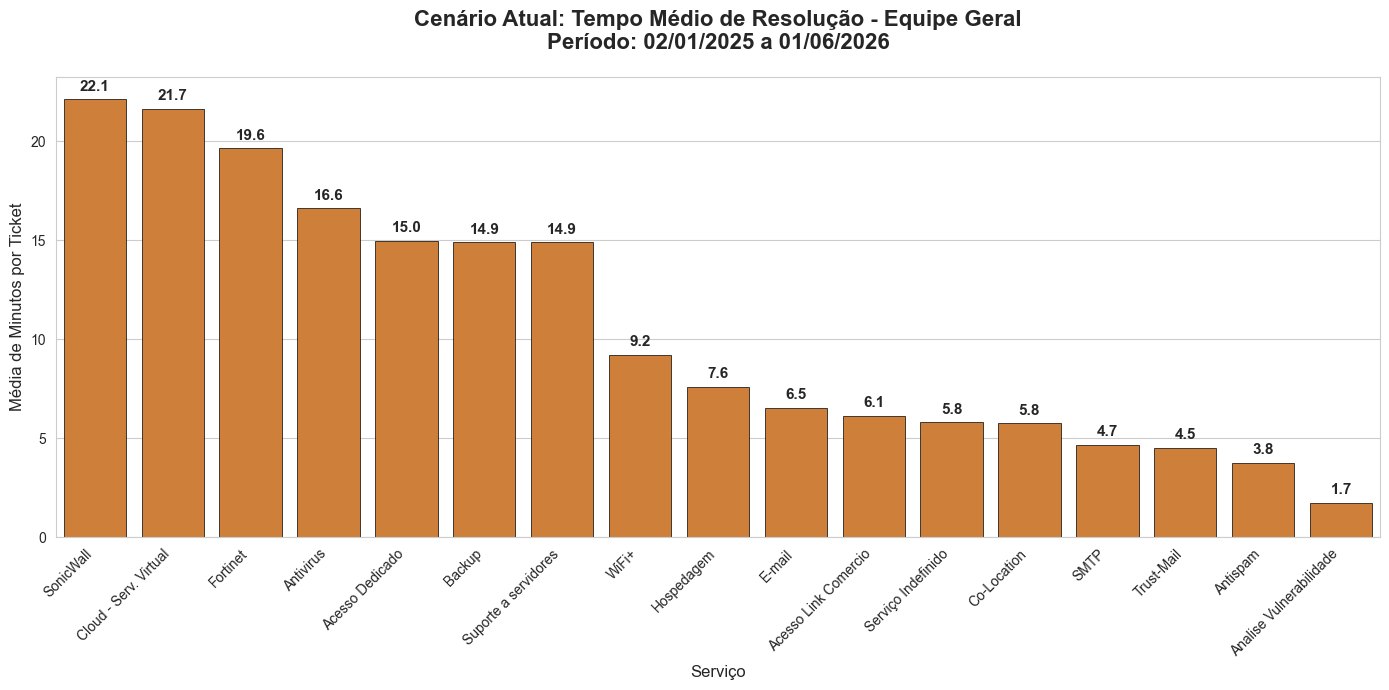


DADOS PARA O LEVANTAMENTO DE CUSTOS (EQUIPE GERAL)
• SonicWall..................... TMA Atual: 22.1 min
• Cloud - Serv. Virtual......... TMA Atual: 21.7 min
• Fortinet...................... TMA Atual: 19.6 min
• Antivirus..................... TMA Atual: 16.6 min
• Acesso Dedicado............... TMA Atual: 15.0 min
• Backup........................ TMA Atual: 14.9 min
• Suporte a servidores.......... TMA Atual: 14.9 min
• WiFi+......................... TMA Atual: 9.2 min
• Hospedagem.................... TMA Atual: 7.6 min
• E-mail........................ TMA Atual: 6.5 min
• Acesso Link Comercio.......... TMA Atual: 6.1 min
• Serviço Indefinido............ TMA Atual: 5.8 min
• Co-Location................... TMA Atual: 5.8 min
• SMTP.......................... TMA Atual: 4.7 min
• Trust-Mail.................... TMA Atual: 4.5 min
• Antispam...................... TMA Atual: 3.8 min
• Analise Vulnerabilidade....... TMA Atual: 1.7 min


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. FILTRAGEM: APENAS EQUIPE GERAL (O "GERALZÃO")
# =========================================================
# Selecionamos apenas os dados da Equipe Geral para mostrar o cenário atual
df_geral_grafico = df_filtrado[df_filtrado['equipe'] == 'Equipe Geral'].copy()

# Calculamos a média por serviço para garantir a ordenação
df_resumo_geral = df_geral_grafico.groupby('servico')['minutos_num'].mean().reset_index()
df_resumo_geral = df_resumo_geral.sort_values('minutos_num', ascending=False)

# =========================================================
# 2. GRÁFICO: PERFORMANCE ATUAL (DOR DO CLIENTE)
# =========================================================
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Cor fixa em Laranja (conforme padrão anterior)
cor_geral = '#e67e22'

plot = sns.barplot(
    data=df_resumo_geral,
    x='servico',
    y='minutos_num',
    color=cor_geral,
    edgecolor='black',
    linewidth=0.5
)

# Título focado no Storytelling de Custo
plt.title(f'Cenário Atual: Tempo Médio de Resolução - Equipe Geral\nPeríodo: {data_inicio} a {data_fim}', 
          fontsize=16, fontweight='bold', pad=20)

plt.ylabel('Média de Minutos por Ticket', fontsize=12)
plt.xlabel('Serviço', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Adicionar os valores acima das barras para o cálculo de custos
for p in plot.patches:
    if p.get_height() > 0:
        plot.annotate(format(p.get_height(), '.1f'), 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha = 'center', va = 'center', 
                      xytext = (0, 9), 
                      textcoords = 'offset points',
                      fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================
# 3. TABELA DE APOIO PARA O SLIDE DE CUSTOS
# =========================================================
print("\n" + "="*60)
print("DADOS PARA O LEVANTAMENTO DE CUSTOS (EQUIPE GERAL)")
print("="*60)
for _, row in df_resumo_geral.iterrows():
    print(f"• {row['servico']:.<30} TMA Atual: {row['minutos_num']:.1f} min")

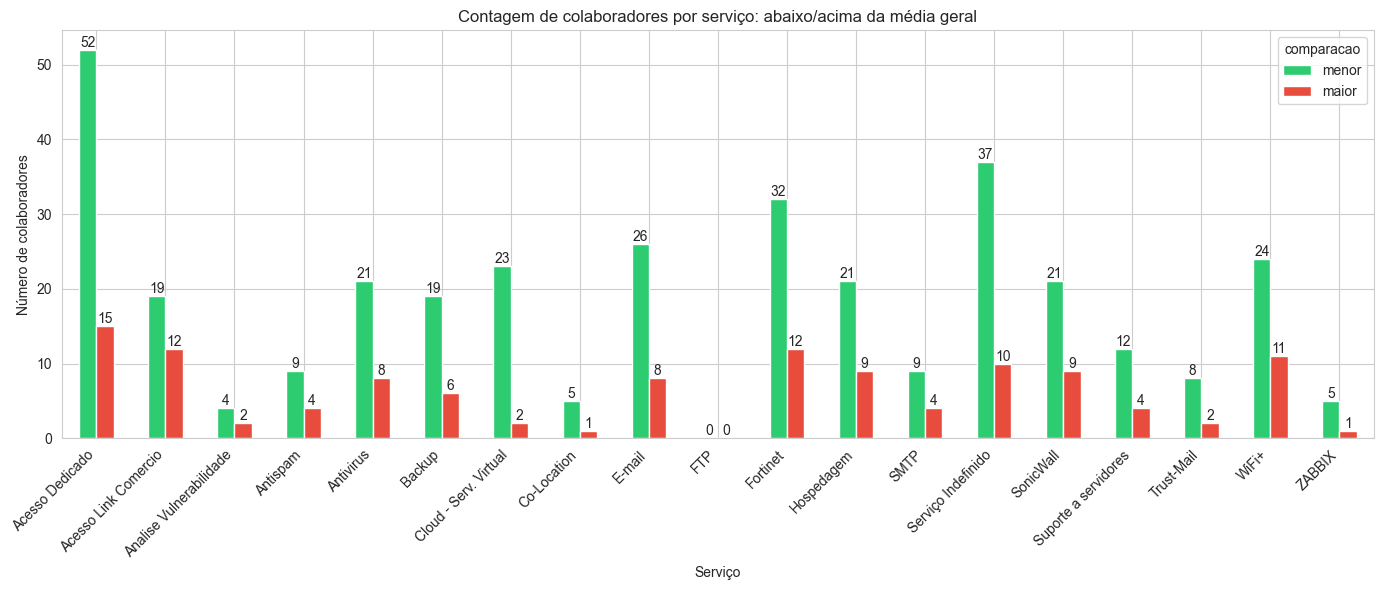


Resumo por serviço:


comparacao,menor,maior,igual
servico,,,
Acesso Dedicado,52,15,0
Acesso Link Comercio,19,12,0
Analise Vulnerabilidade,4,2,0
Antispam,9,4,0
Antivirus,21,8,0
Backup,19,6,0
Cloud - Serv. Virtual,23,2,0
Co-Location,5,1,0
E-mail,26,8,0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Célula final: comparar médias por colaborador vs média geral por serviço e plotar contagem
# Filtrar base (tickets fechados, minutos válidos)
df_base = df[(df['status_cliente'] == 'FECHADO') & (df['minutos_num'].notna())].copy()

# Média por colaborador por serviço
media_colab = df_base.groupby(['servico', 'colaborador'])['minutos_num'].mean().reset_index(name='media_colaborador')
# Média geral por serviço
media_servico = df_base.groupby('servico')['minutos_num'].mean().reset_index(name='media_geral')

# Juntar e classificar
df_comp = media_colab.merge(media_servico, on='servico', how='left')
df_comp['comparacao'] = np.where(df_comp['media_colaborador'] < df_comp['media_geral'], 'menor',
                                 np.where(df_comp['media_colaborador'] > df_comp['media_geral'], 'maior', 'igual'))

# Contagem de colaboradores únicos por serviço e classificação
contagem = df_comp.groupby(['servico', 'comparacao'])['colaborador'].nunique().unstack(fill_value=0)
for c in ['menor','maior','igual']:
    if c not in contagem.columns:
        contagem[c] = 0
contagem = contagem[['menor','maior','igual']]

# Plot: quantos colaboradores estão abaixo/acima da média geral por serviço
sns.set_style('whitegrid')
ax = contagem[['menor','maior']].plot(kind='bar', figsize=(14,6), color=['#2ecc71','#e74c3c'])
plt.title('Contagem de colaboradores por serviço: abaixo/acima da média geral')
plt.ylabel('Número de colaboradores')
plt.xlabel('Serviço')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

print('\nResumo por serviço:')
display(contagem)


In [14]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# =========================================================
# 1. PREPARAÇÃO DA BASE DE DADOS
# =========================================================
df_vol_base = df.groupby(['colaborador', 'servico'])['id_ticket'].nunique().reset_index(name='xp_acumulado')
df_vol_base['xp_acumulado'] = df_vol_base['xp_acumulado'].astype(float)

todos_servicos = sorted(df_vol_base['servico'].unique())

# =========================================================
# 2. PAINEL DE GESTÃO DE EQUIPE
# =========================================================
while True:
    colaboradores_unicos = sorted(df_vol_base['colaborador'].unique())
    id_map = {f"{i+1:03d}": colab for i, colab in enumerate(colaboradores_unicos)}
    id_reverse_map = {colab: uid for uid, colab in id_map.items()}

    print("\n" + "="*60)
    print("  PAINEL DE GESTÃO E CONFIGURAÇÃO DE EQUIPE")
    print("="*60)
    print("[ 1 ] Visualizar Lista Atual de Colaboradores")
    print("[ 2 ] Cadastrar Novo Colaborador")
    print("[ 3 ] Excluir Colaborador Permanentemente")
    print("[ 4 ] Resetar XP de um Colaborador")
    print("[ 5 ] Fechar Gestão e Avançar para Escala Diária")
    print("="*60)

    opcao = input("Escolha uma opção: ").strip()

    if opcao == '1':
        print("\nCOLABORADORES CADASTRADOS:")
        for uid, colab in id_map.items():
            print(f" [{uid}] - {colab}")

    elif opcao == '2':
        print("\nCADASTRO DE NOVO TÉCNICO")
        novo_nome = input("Digite o nome completo do colaborador: ").strip()
        if novo_nome in df_vol_base['colaborador'].values:
            print("Este colaborador já está cadastrado no sistema.")
        elif novo_nome == "":
            print("Nome inválido.")
        else:
            novas_linhas = pd.DataFrame([
                {'colaborador': novo_nome, 'servico': s, 'xp_acumulado': 0.0}
                for s in todos_servicos
            ])
            df_vol_base = pd.concat([df_vol_base, novas_linhas], ignore_index=True)
            print(f"{novo_nome} cadastrado com sucesso em todos os setores!")

    elif opcao == '3':
        print("\nEXCLUSÃO PERMANENTE DE COLABORADOR")
        id_alvo = input("Digite o ID do colaborador que deseja remover: ").strip()
        if id_alvo in id_map:
            nome_alvo = id_map[id_alvo]
            confirmar = input(f"Tem certeza que deseja apagar permanentemente {nome_alvo}? (S/N): ").strip().upper()
            if confirmar == 'S':
                df_vol_base = df_vol_base[df_vol_base['colaborador'] != nome_alvo].reset_index(drop=True)
                print(f"{nome_alvo} foi removido com sucesso.")
        else:
            print("ID não encontrado.")

    elif opcao == '4':
        print("\nRESETAR PROFICIÊNCIA (XP)")
        id_alvo = input("Digite o ID do colaborador: ").strip()
        if id_alvo in id_map:
            nome_alvo = id_map[id_alvo]
            print("\nServiços disponíveis:")
            for idx, s in enumerate(todos_servicos):
                print(f" [{idx}] {s}")
            idx_serv = input(f"Selecione o número do serviço para zerar o XP de {nome_alvo}: ").strip()
            try:
                servico_alvo = todos_servicos[int(idx_serv)]
                df_vol_base.loc[
                    (df_vol_base['colaborador'] == nome_alvo) &
                    (df_vol_base['servico'] == servico_alvo),
                    'xp_acumulado'
                ] = 0.0
                print(f"XP de {nome_alvo} no setor {servico_alvo} foi resetado para 0.0!")
            except (ValueError, IndexError):
                print("Seleção de serviço inválida.")
        else:
            print("ID não encontrado.")

    elif opcao == '5':
        print("\nConfigurações salvas. Avançando para o Grid Matinal...")
        break
    else:
        print("Opção inválida.")

# Atualização final dos mapas após ajustes no painel
colaboradores_unicos = sorted(df_vol_base['colaborador'].unique())
id_map = {f"{i+1:03d}": colab for i, colab in enumerate(colaboradores_unicos)}
id_reverse_map = {colab: uid for uid, colab in id_map.items()}

# =========================================================
# 3. CHAMADA MATINAL
# =========================================================
print("\n" + "="*60)
print("PAINEL DE CHAMADA MATINAL - SELECIONE OS PRESENTES")
print("="*60)
for uid, colab in id_map.items():
    print(f"[{uid}] - {colab}")
print("="*60)

disponiveis_ids = []
print("\nDigite os IDs dos técnicos presentes hoje (Digite '000' para encerrar):")
while True:
    entrada = input("ID: ").strip()
    if entrada == '000':
        break
    if entrada in id_map and entrada not in disponiveis_ids:
        disponiveis_ids.append(entrada)
        print(f"{id_map[entrada]} integrado à escala.")
    elif entrada not in id_map:
        print("ID não encontrado.")

colaboradores_presentes = [id_map[uid] for uid in disponiveis_ids]
if not colaboradores_presentes:
    print("Operação abortada por falta de equipe ativa hoje.")
    exit()

# =========================================================
# 4. TRATAMENTO ESTATÍSTICO — ÚLTIMOS 30 DIAS
# CORREÇÃO PRINCIPAL: evitar KeyError no groupby após apply no pandas 3.x
# =========================================================
df['data_criacao_ticket'] = pd.to_datetime(df['data_criacao_ticket'], errors='coerce')
limite_30_dias = df['data_criacao_ticket'].max() - timedelta(days=30)
df_30_dias = df[df['data_criacao_ticket'] >= limite_30_dias].copy()

# Conversão robusta de duracao_minutos_total_por_ticket para minutos
df_30_dias['minutos_num'] = (
    pd.to_timedelta(df_30_dias['duracao_minutos_total_por_ticket'], errors='coerce')
    .dt.total_seconds() / 60
)

# CORREÇÃO: remoção de outliers por IQR sem groupby+apply que quebra no pandas 3.x
# Fazemos manualmente para preservar o índice e a coluna 'servico'
def remover_outliers_iqr(df_input):
    resultado = []
    for servico, grupo in df_input.groupby('servico'):
        q1 = grupo['minutos_num'].quantile(0.25)
        q3 = grupo['minutos_num'].quantile(0.75)
        iqr = q3 - q1
        limite_superior = max(q3 + 1.5 * iqr, 45)
        resultado.append(grupo[grupo['minutos_num'] <= limite_superior])
    if resultado:
        return pd.concat(resultado, ignore_index=True)
    return pd.DataFrame(columns=df_input.columns)

df_filtrado = remover_outliers_iqr(df_30_dias)

# Mapeia colaboradores do "Geralzão" (nunca atingiram 200 XP em nenhum serviço)
colab_com_200 = df_vol_base[df_vol_base['xp_acumulado'] >= 200]['colaborador'].unique()
colaboradores_geral = df_vol_base[
    ~df_vol_base['colaborador'].isin(colab_com_200)
]['colaborador'].unique()

# CORREÇÃO: checar se df_filtrado está vazio antes de agrupar
if df_filtrado.empty:
    print("Aviso: nenhum dado nos últimos 30 dias após remoção de outliers. Usando base completa.")
    df_filtrado = df_30_dias.copy()

media_geral_servico = (
    df_filtrado[df_filtrado['colaborador'].isin(colaboradores_geral)]
    .groupby('servico')['minutos_num'].mean()
)
media_especialista_servico = (
    df_filtrado[~df_filtrado['colaborador'].isin(colaboradores_geral)]
    .groupby('servico')['minutos_num'].mean()
)

# Serviços onde especialistas NÃO superam o geral (candidatos a desmembramento)
servicos_para_desmembrar = []
for serv in media_especialista_servico.index:
    media_esp = media_especialista_servico.get(serv)
    media_ger = media_geral_servico.get(serv, np.nan)
    # CORREÇÃO: só desmembra se tiver dado do geral para comparar
    if pd.notna(media_ger) and media_esp >= media_ger:
        servicos_para_desmembrar.append(serv)

# Especialistas presentes e qualificados
especialistas_vivos = df_vol_base[
    (df_vol_base['xp_acumulado'] >= 200) &
    (~df_vol_base['servico'].isin(servicos_para_desmembrar)) &
    (df_vol_base['colaborador'].isin(colaboradores_presentes))
].copy()

# =========================================================
# 5. ALOCAÇÃO MATRICIAL (PILOTO / CO-PILOTO)
# =========================================================
escala_duplas = {servico: {'Piloto': None, 'Co_Piloto': []} for servico in todos_servicos}
alocados = set()

# Prioriza setores com menos especialistas disponíveis
escassez_setor = {}
for s in todos_servicos:
    n = len(especialistas_vivos[especialistas_vivos['servico'] == s])
    escassez_setor[s] = n if n > 0 else 999

setores_ordenados = sorted(escassez_setor, key=lambda k: escassez_setor[k])

# Aloca Pilotos: maior XP no serviço, ainda não alocado
for servico in setores_ordenados:
    candidatos = (
        especialistas_vivos[especialistas_vivos['servico'] == servico]
        .sort_values('xp_acumulado', ascending=False)
    )
    for _, candidato in candidatos.iterrows():
        nome = candidato['colaborador']
        if nome not in alocados:
            escala_duplas[servico]['Piloto'] = nome
            alocados.add(nome)
            break

# Aloca Co-Pilotos com os que sobraram
sobrou = [c for c in colaboradores_presentes if c not in alocados]
for colab in sobrou:
    alocado = False
    for servico in todos_servicos:
        # CORREÇÃO: Co-Piloto só entra onde há Piloto e ainda não tem Co-Piloto
        if escala_duplas[servico]['Piloto'] is not None and len(escala_duplas[servico]['Co_Piloto']) < 1:
            escala_duplas[servico]['Co_Piloto'].append(colab)
            alocados.add(colab)
            alocado = True
            break
    if not alocado:
        # Transbordo: Co-Piloto extra no setor com Piloto e menos Co-Pilotos
        servico_transborde = min(
            [s for s in todos_servicos if escala_duplas[s]['Piloto'] is not None],
            key=lambda s: len(escala_duplas[s]['Co_Piloto']),
            default=todos_servicos[0]
        )
        escala_duplas[servico_transborde]['Co_Piloto'].append(colab)

# Exibe grid operacional
print("\n" + "="*60)
print("GRID OPERACIONAL DO DIA")
print("="*60)
for s, time in escala_duplas.items():
    p = time['Piloto'] if time['Piloto'] else "SEM PILOTO — SESSAO COLETIVA"
    c_p = ", ".join(time['Co_Piloto']) if time['Co_Piloto'] else "Sem Co-Piloto"
    print(f"SETOR: {s}")
    print(f"  PILOTO:    {p}")
    print(f"  CO-PILOTO: {c_p}")
    print("-" * 45)

# =========================================================
# 6. FECHAMENTO E ATUALIZAÇÃO DE XP
# =========================================================
print("\n" + "="*60)
print("FECHAMENTO DO EXPEDIENTE — CRÉDITOS DE XP")
print("="*60)

log_fechamento = []
for servico, componentes in escala_duplas.items():
    if componentes['Piloto']:
        log_fechamento.append({
            'colaborador': componentes['Piloto'],
            'servico': servico,
            'tickets_fechados': 10,
            'papel': 'Piloto'
        })
        for cp in componentes['Co_Piloto']:
            log_fechamento.append({
                'colaborador': cp,
                'servico': servico,
                'tickets_fechados': 6,
                'papel': 'Co-Piloto'
            })

df_producao = pd.DataFrame(log_fechamento)

for _, linha in df_producao.iterrows():
    nome = linha['colaborador']
    serv = linha['servico']
    # CORREÇÃO: fator fixo por papel, sem flag redundante 'copiloto_validado'
    fator = 1.0 if linha['papel'] == 'Piloto' else 0.5
    xp_ganho = linha['tickets_fechados'] * fator

    idx = df_vol_base[
        (df_vol_base['colaborador'] == nome) &
        (df_vol_base['servico'] == serv)
    ].index

    if not idx.empty:
        xp_antigo = df_vol_base.loc[idx[0], 'xp_acumulado']
        df_vol_base.loc[idx[0], 'xp_acumulado'] += xp_ganho
        xp_novo = df_vol_base.loc[idx[0], 'xp_acumulado']

        uid = id_reverse_map.get(nome, "???")
        print(f"[{uid}] {nome} ({linha['papel']}) em {serv}: +{xp_ganho} XP | {xp_antigo:.1f} -> {xp_novo:.1f}")

        if xp_antigo < 200.0 <= xp_novo:
            print(f"      >>> EVOLUCAO: {nome} atingiu 200 XP e virou ESPECIALISTA em {serv}!")
        print("-" * 45)
    else:
        # CORREÇÃO: colaborador novo (cadastrado no painel) não tem linha em df_vol_base para serv
        nova_linha = pd.DataFrame([{
            'colaborador': nome,
            'servico': serv,
            'xp_acumulado': xp_ganho
        }])
        df_vol_base = pd.concat([df_vol_base, nova_linha], ignore_index=True)
        uid = id_reverse_map.get(nome, "???")
        print(f"[{uid}] {nome} ({linha['papel']}) em {serv}: +{xp_ganho} XP | Nova entrada criada.")
        print("-" * 45)


  PAINEL DE GESTÃO E CONFIGURAÇÃO DE EQUIPE
[ 1 ] Visualizar Lista Atual de Colaboradores
[ 2 ] Cadastrar Novo Colaborador
[ 3 ] Excluir Colaborador Permanentemente
[ 4 ] Resetar XP de um Colaborador
[ 5 ] Fechar Gestão e Avançar para Escala Diária

Configurações salvas. Avançando para o Grid Matinal...

PAINEL DE CHAMADA MATINAL - SELECIONE OS PRESENTES
[001] - 3 - NJ2
[002] - 3 - Netclick
[003] - 3 - RP1
[004] - 3 - RP2
[005] - 3 - RR
[006] - Allan
[007] - André
[008] - Arnizal
[009] - Arthur
[010] - Breno Gabriel
[011] - Bruno
[012] - Camila
[013] - Carlos Alberto
[014] - Cleverton
[015] - Colaborador Indefinido
[016] - Daniel
[017] - Danilo
[018] - Davi
[019] - Eduardo
[020] - Elaine
[021] - Emerson
[022] - Endrew
[023] - Ermerson
[024] - Felipe
[025] - Fernanda
[026] - Flavio
[027] - Gabriel
[028] - Guilherme Coelho
[029] - Gustavo
[030] - Gustavo Avelar
[031] - Hillara Rafaela
[032] - Isabella
[033] - Janaina
[034] - Jeferson
[035] - Jeison
[036] - Jhennifer
[037] - José
[038] -